In [2]:
pip install transformers

In [3]:
import torch
from transformers import ViTImageProcessor, ViTForImageClassification
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
torch.manual_seed(0)
# if torch.backends.mps.is_available():
#     device=torch.device("mps")
# else:
#     device=torch.device("cpu")
# print(device)
if torch.cuda.is_available():
    device=torch.device("cuda")
elif torch.backends.mps.is_available():
    device=torch.device("mps")
else:
    device=torch.device("cpu")

In [4]:
processor=ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
vit_model=ViTForImageClassification.from_pretrained("google/vit-base-patch16-224",output_attentions=True)
vit_model=vit_model.to(device)
vit_model.eval()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [6]:
from PIL import Image

image=Image.open("ball.jpg").convert("RGB")
inputs=processor(images=image,return_tensors="pt").to(device)
with torch.no_grad():
    outputs=vit_model(**inputs)
probabilities=torch.softmax(outputs.logits,dim=-1)
top5_probabilities,top5_indices=torch.topk(probabilities,5)
for i in range(0,5):
    index=top5_indices[0][i].item()
    probability=top5_probabilities[0][i].item()
    label=vit_model.config.id2label[index]
    print(label,probability)

rugby ball 0.8704355955123901
soccer ball 0.12370245903730392
volleyball 0.0021454256493598223
baseball 0.0003241274389438331
golf ball 0.0003198689082637429


In [ ]:
last_layer_attention=outputs.attentions[-1]
attention=last_layer_attention[0].mean(dim=0) #197
cls_attention=attention[0,1:]
attention_grid=cls_attention.reshape(14,14).cpu().numpy()

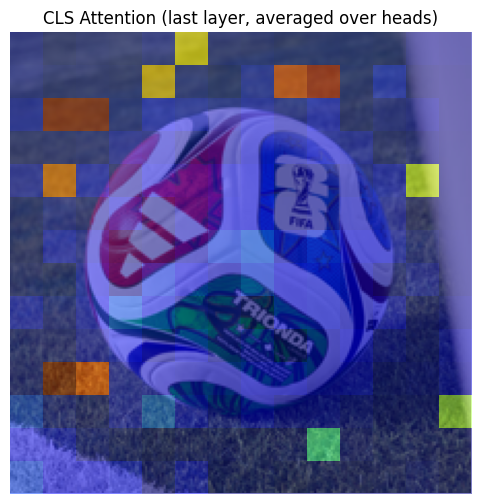

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(image.resize((224,224)))
plt.imshow(attention_grid,cmap="jet",alpha=0.5,extent=(0,224,224,0))
plt.title("CLS Attention (last layer, averaged over heads)")
plt.axis("off")
plt.savefig("attention_overlay.png",bbox_inches="tight")
plt.show()

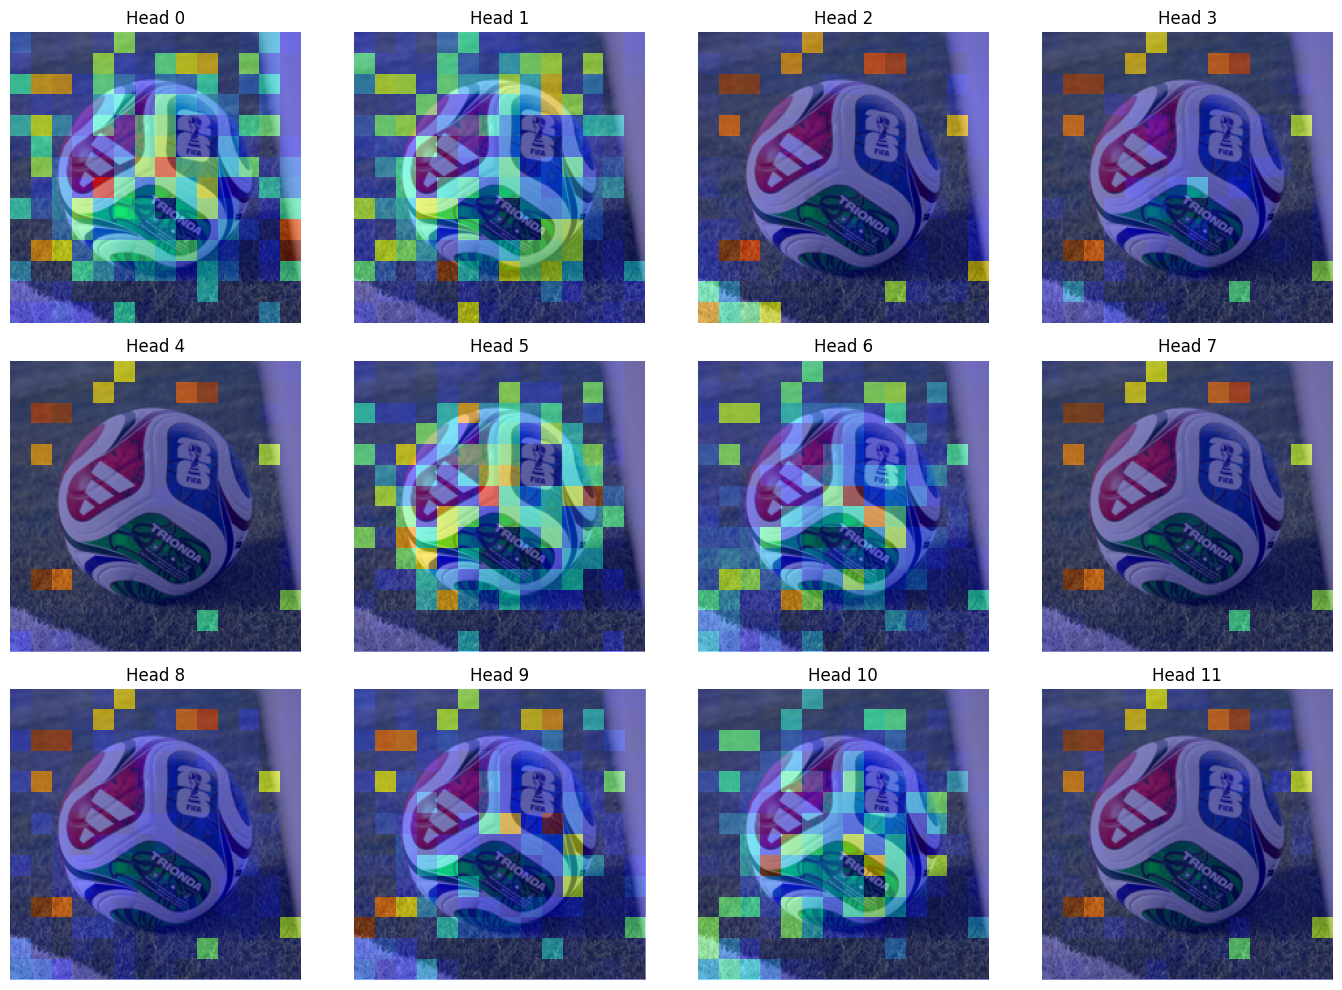

In [ ]:
last_layer=outputs.attentions[-1]
num_heads=last_layer.shape[1]

fig,axes=plt.subplots(3,4,figsize=(14,10))
for head in range(num_heads):
    head_attention=last_layer[0,head]
    cls_to_patches=head_attention[0,1:]
    grid=cls_to_patches.reshape(14,14).cpu().numpy()
    row=head//4
    column=head%4
    axes[row][column].imshow(image.resize((224,224)))
    axes[row][column].imshow(grid,cmap="jet",alpha=0.5,extent=(0,224,224,0))
    axes[row][column].set_title("Head "+str(head))
    axes[row][column].axis("off")

plt.tight_layout()
plt.savefig("attention_heads.png",bbox_inches="tight")
plt.show()

In [ ]:
original_index=torch.softmax(outputs.logits,-1).argmax(-1).item()

def masked_confidence_of_original(image,mask_ratio,mask_type):
    inputs=processor(images=image,return_tensors="pt").to(device)
    pixel_values=inputs["pixel_values"].clone()
    patch_size=16
    grid_size=14
    total_patches=grid_size*grid_size
    num_to_mask=int(mask_ratio*total_patches)

    if mask_type=="random":
        chosen=torch.randperm(total_patches)[:num_to_mask].tolist()
    else:
        chosen=[]
        center=grid_size//2
        offset=int((num_to_mask**0.5)//2)
        for r in range(center-offset,center+offset+1):
            for c in range(center-offset,center+offset+1):
                chosen.append(r*grid_size+c)

    for idx in chosen:
        row=(idx//grid_size)*patch_size
        col=(idx%grid_size)*patch_size
        pixel_values[0,:,row:row+patch_size,col:col+patch_size]=0

    with torch.no_grad():
        out=vit_model(pixel_values=pixel_values)
    probabilities=torch.softmax(out.logits,-1)
    return round(probabilities[0,original_index].item(),4)

for ratio in [0.1,0.3,0.5]:
    print("Ratio",ratio)
    # random: average over 10 seeds
    random_vals=[]
    for seed in range(0,10):
        torch.manual_seed(seed)
        random_vals.append(masked_confidence_of_original(image,ratio,"random"))
    random_mean=np.mean(random_vals)
    random_std=np.std(random_vals)
    print("  random, P(top): mean",round(random_mean,4),"std",round(random_std,4),"raw",random_vals)
    # center: deterministic
    center_val=masked_confidence_of_original(image,ratio,"center")
    print("  center, P(top):",center_val)

Ratio 0.1
  random, P(top): mean 0.9416 std 0.0445 raw [0.945, 0.895, 0.9953, 0.9715, 0.9843, 0.8698, 0.9043, 0.9899, 0.9682, 0.8925]
  center, P(top): 0.9969
Ratio 0.3
  random, P(top): mean 0.8719 std 0.1337 raw [0.6907, 0.9462, 0.9126, 0.8088, 0.9827, 0.7946, 0.6034, 0.9959, 0.9921, 0.9924]
  center, P(top): 0.8849
Ratio 0.5
  random, P(top): mean 0.7605 std 0.2194 raw [0.6341, 0.2642, 0.6914, 0.8648, 0.5714, 0.9596, 0.738, 0.9962, 0.9947, 0.8909]
  center, P(top): 0.1274


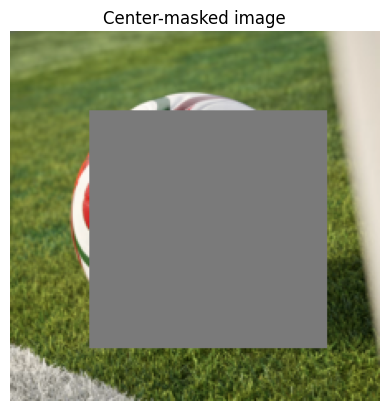

In [ ]:
inputs=processor(images=image,return_tensors="pt").to(device)
pixel_values=inputs["pixel_values"].clone()
patch_size=16
grid_size=14
num_to_mask=int(0.5*196)
center=grid_size//2
offset=int((num_to_mask**0.5)//2)
chosen=[]
for r in range(center-offset,center+offset+1):
    for c in range(center-offset,center+offset+1):
        chosen.append(r*grid_size+c)
for idx in chosen:
    row=(idx//grid_size)*patch_size
    col=(idx%grid_size)*patch_size
    pixel_values[0,:,row:row+patch_size,col:col+patch_size]=0

img_view=pixel_values[0].cpu().permute(1,2,0).numpy()
img_view=(img_view-img_view.min())/(img_view.max()-img_view.min())
plt.imshow(img_view)
plt.title("Center-masked image")
plt.axis("off")
plt.savefig("masked_center.png",bbox_inches="tight")
plt.show()

Image was not central so could be the reason

In [ ]:
from transformers import ViTModel

feature_vit=ViTModel.from_pretrained("google/vit-base-patch16-224").to(device)
feature_vit.eval()

def extract_features(images):
    inputs=processor(images=images,return_tensors="pt").to(device)
    with torch.no_grad():
        outputs=feature_vit(**inputs)
    hidden=outputs.last_hidden_state
    cls_features=hidden[:,0,:]
    mean_features=hidden[:,1:,:].mean(dim=1)
    return cls_features.cpu(),mean_features.cpu()

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from torchvision import datasets
cifar_train=datasets.CIFAR10(root="./data",train=True,download=True)
cifar_test=datasets.CIFAR10(root="./data",train=False,download=True)
def build_feature_set(dataset,num_images):
    cls_list=[]
    mean_list=[]
    label_list=[]
    for i in range(num_images):
        pil_image,label=dataset[i]
        cls_feat,mean_feat=extract_features(pil_image)
        cls_list.append(cls_feat)
        mean_list.append(mean_feat)
        label_list.append(label)
    cls_features=torch.cat(cls_list).numpy()
    mean_features=torch.cat(mean_list).numpy()
    labels=label_list
    return cls_features,mean_features,labels
train_cls,train_mean,train_labels=build_feature_set(cifar_train,1000)
test_cls,test_mean,test_labels=build_feature_set(cifar_test,300)

100%|██████████| 170M/170M [31:25<00:00, 90.4kB/s]


In [ ]:
from sklearn.linear_model import LogisticRegression

cls_probe=LogisticRegression(max_iter=1000)
cls_probe.fit(train_cls,train_labels)
cls_accuracy=cls_probe.score(test_cls,test_labels)
mean_probe=LogisticRegression(max_iter=1000)
mean_probe.fit(train_mean,train_labels)
mean_accuracy=mean_probe.score(test_mean,test_labels)

print("CLS token probe accuracy:",cls_accuracy)
print("Mean-pool probe accuracy:",mean_accuracy)

CLS token probe accuracy: 0.96
Mean-pool probe accuracy: 0.95


In [7]:
rugby_index=None
soccer_index=None
for class_index,class_name in vit_model.config.id2label.items():
    if class_name=="rugby ball":
        rugby_index=class_index
    if class_name=="soccer ball":
        soccer_index=class_index

def masked_class_breakdown(image,mask_ratio,mask_type):
    inputs=processor(images=image,return_tensors="pt").to(device)
    pixel_values=inputs["pixel_values"].clone()
    patch_size=16
    grid_size=14
    total_patches=grid_size*grid_size
    num_to_mask=int(mask_ratio*total_patches)

    if mask_type=="random":
        chosen=torch.randperm(total_patches)[:num_to_mask].tolist()
    else:
        chosen=[]
        center=grid_size//2
        offset=int((num_to_mask**0.5)//2)
        for r in range(center-offset,center+offset+1):
            for c in range(center-offset,center+offset+1):
                chosen.append(r*grid_size+c)

    for idx in chosen:
        row=(idx//grid_size)*patch_size
        col=(idx%grid_size)*patch_size
        pixel_values[0,:,row:row+patch_size,col:col+patch_size]=0

    with torch.no_grad():
        out=vit_model(pixel_values=pixel_values)
    probabilities=torch.softmax(out.logits,-1)
    p_rugby=round(probabilities[0,rugby_index].item(),4)
    p_soccer=round(probabilities[0,soccer_index].item(),4)
    top_index=probabilities[0].argmax().item()
    top_label=vit_model.config.id2label[top_index]
    return p_rugby,p_soccer,top_label

print("unmasked:")
print("  P(rugby ball): ",round(torch.softmax(outputs.logits,-1)[0,rugby_index].item(),4))
print("  P(soccer ball):",round(torch.softmax(outputs.logits,-1)[0,soccer_index].item(),4))
print()

for ratio in [0.1,0.3,0.5]:
    print("Ratio",ratio)

    rugby_vals=[]
    soccer_vals=[]
    flip_count=0
    for seed in range(0,10):
        torch.manual_seed(seed)
        p_rugby,p_soccer,top_label=masked_class_breakdown(image,ratio,"random")
        rugby_vals.append(p_rugby)
        soccer_vals.append(p_soccer)
        if top_label!="rugby ball":
            flip_count=flip_count+1
    print("  random: P(rugby) mean",round(np.mean(rugby_vals),4),
          " P(soccer) mean",round(np.mean(soccer_vals),4),
          " label changed in",flip_count,"of 10 seeds")

    p_rugby,p_soccer,top_label=masked_class_breakdown(image,ratio,"center")
    print("  center: P(rugby)",p_rugby,
          " P(soccer)",p_soccer,
          " predicted class:",top_label)

unmasked:
  P(rugby ball):  0.8704
  P(soccer ball): 0.1237

Ratio 0.1
  random: P(rugby) mean 0.9416  P(soccer) mean 0.0543  label changed in 0 of 10 seeds
  center: P(rugby) 0.9969  P(soccer) 0.0018  predicted class: rugby ball
Ratio 0.3
  random: P(rugby) mean 0.8719  P(soccer) mean 0.1209  label changed in 0 of 10 seeds
  center: P(rugby) 0.8849  P(soccer) 0.0998  predicted class: rugby ball
Ratio 0.5
  random: P(rugby) mean 0.7605  P(soccer) mean 0.1691  label changed in 1 of 10 seeds
  center: P(rugby) 0.1274  P(soccer) 0.7375  predicted class: soccer ball
